### Welcome to the exercise about observational studies! This exercise will be hands on, and you will be able to practise the skills you developed so far!

## Propensity score matching

In this exercise, you will apply [propensity score matching](http://www.stewartschultz.com/statistics/books/Design%20of%20observational%20studies.pdf), which we discussed in lecture 6 ("Observational studies"), in order to draw conclusions from an observational study.

We will work with a by-now classic dataset from Robert LaLonde's study "[Evaluating the Econometric Evaluations of Training Programs](http://people.hbs.edu/nashraf/LaLonde_1986.pdf)" (1986).
The study investigated the effect of a job training program ("National Supported Work Demonstration") on the real earnings of an individual, a couple of years after completion of the program.
Your task is to determine the effectiveness of the "treatment" represented by the job training program.

#### Dataset description

- `treat`: 1 if the subject participated in the job training program, 0 otherwise
- `age`: the subject's age
- `educ`: years of education
- `race`: categorical variable with three possible values: Black, Hispanic, or White
- `married`: 1 if the subject was married at the time of the training program, 0 otherwise
- `nodegree`: 1 if the subject has earned no school degree, 0 otherwise
- `re74`: real earnings in 1974 (pre-treatment)
- `re75`: real earnings in 1975 (pre-treatment)
- `re78`: real earnings in 1978 (outcome)

If you want to deepen your knowledge on propensity scores and observational studies, we highly recommend Rosenbaum's excellent book on the ["Design of Observational Studies"](http://www.stewartschultz.com/statistics/books/Design%20of%20observational%20studies.pdf). Even just reading the first chapter (18 pages) will help you a lot.

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import ttest_ind
%matplotlib inline

data_folder = './data/'
df = pd.read_csv(data_folder + 'lalonde.csv')

In [2]:
df.sample(10)

,id,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
177,NSW178,1,33,11,1,0,0,1,0.0000,7867.91600,6281.4330
405,PSID221,0,19,12,0,0,0,0,815.0550,964.98390,12059.7300
469,PSID285,0,17,10,0,0,0,1,0.0000,152.17740,10301.2300
529,PSID345,0,17,9,1,0,0,1,1222.5820,0.00000,422.6298
475,PSID291,0,16,6,1,0,0,1,0.0000,44.75806,0.0000
563,PSID379,0,33,12,0,1,1,0,0.0000,0.00000,5841.4530
539,PSID355,0,19,9,1,0,0,1,384.0163,0.00000,0.0000
310,PSID126,0,27,12,0,0,1,0,4043.9270,3231.53200,7240.8600
112,NSW113,1,20,12,1,0,0,0,989.2678,165.20770,0.0000
264,PSID80,0,23,8,0,0,1,1,3595.2550,4866.09700,2782.5590


## 1. A naive analysis

Compare the distribution of the outcome variable (`re78`) between the two groups, using plots and numbers.
To summarize and compare the distributions, you may use the techniques we discussed in lecture 4 ("Descibing data") and 3 ("Visualizing data").

What might a naive "researcher" conclude from this superficial analysis?

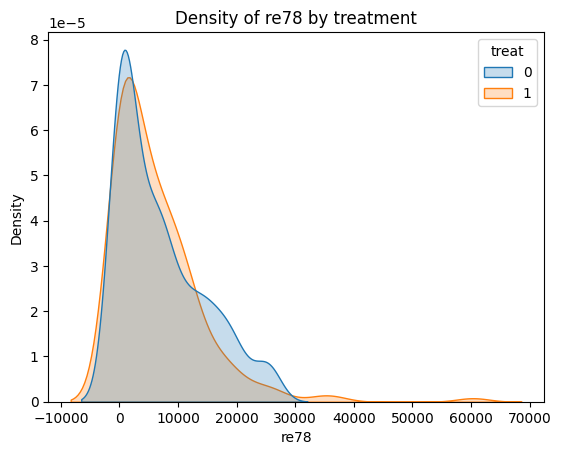

Mean for treated : 6349.143530270271 std : 7867.402217734687
Mean for not treated : 6984.169742307692 std : 7294.161790868405


AttributeError: module 'numpy' has no attribute 'AxisError'

In [ ]:
sns.kdeplot(data=df, x='re78', hue='treat', fill=True, common_norm=False)
plt.title("Density of re78 by treatment")
plt.show()
print(f"Mean for treated : {df[df['treat']==1]['re78'].mean()} std : {df[df['treat']==1]['re78'].std()}")
print(f"Mean for not treated : {df[df['treat']==0]['re78'].mean()} std : {df[df['treat']==0]['re78'].std()}")

We observe no significant difference between the two groups

## 2. A closer look at the data

You're not naive, of course (and even if you are, you've learned certain things in ADA), so you aren't content with a superficial analysis such as the above.
You're aware of the dangers of observational studies, so you take a closer look at the data before jumping to conclusions.

For each feature in the dataset, compare its distribution in the treated group with its distribution in the control group, using plots and numbers.
As above, you may use the techniques we discussed in class for summarizing and comparing the distributions.

What do you observe?
Describe what your observations mean for the conclusions drawn by the naive "researcher" from his superficial analysis.

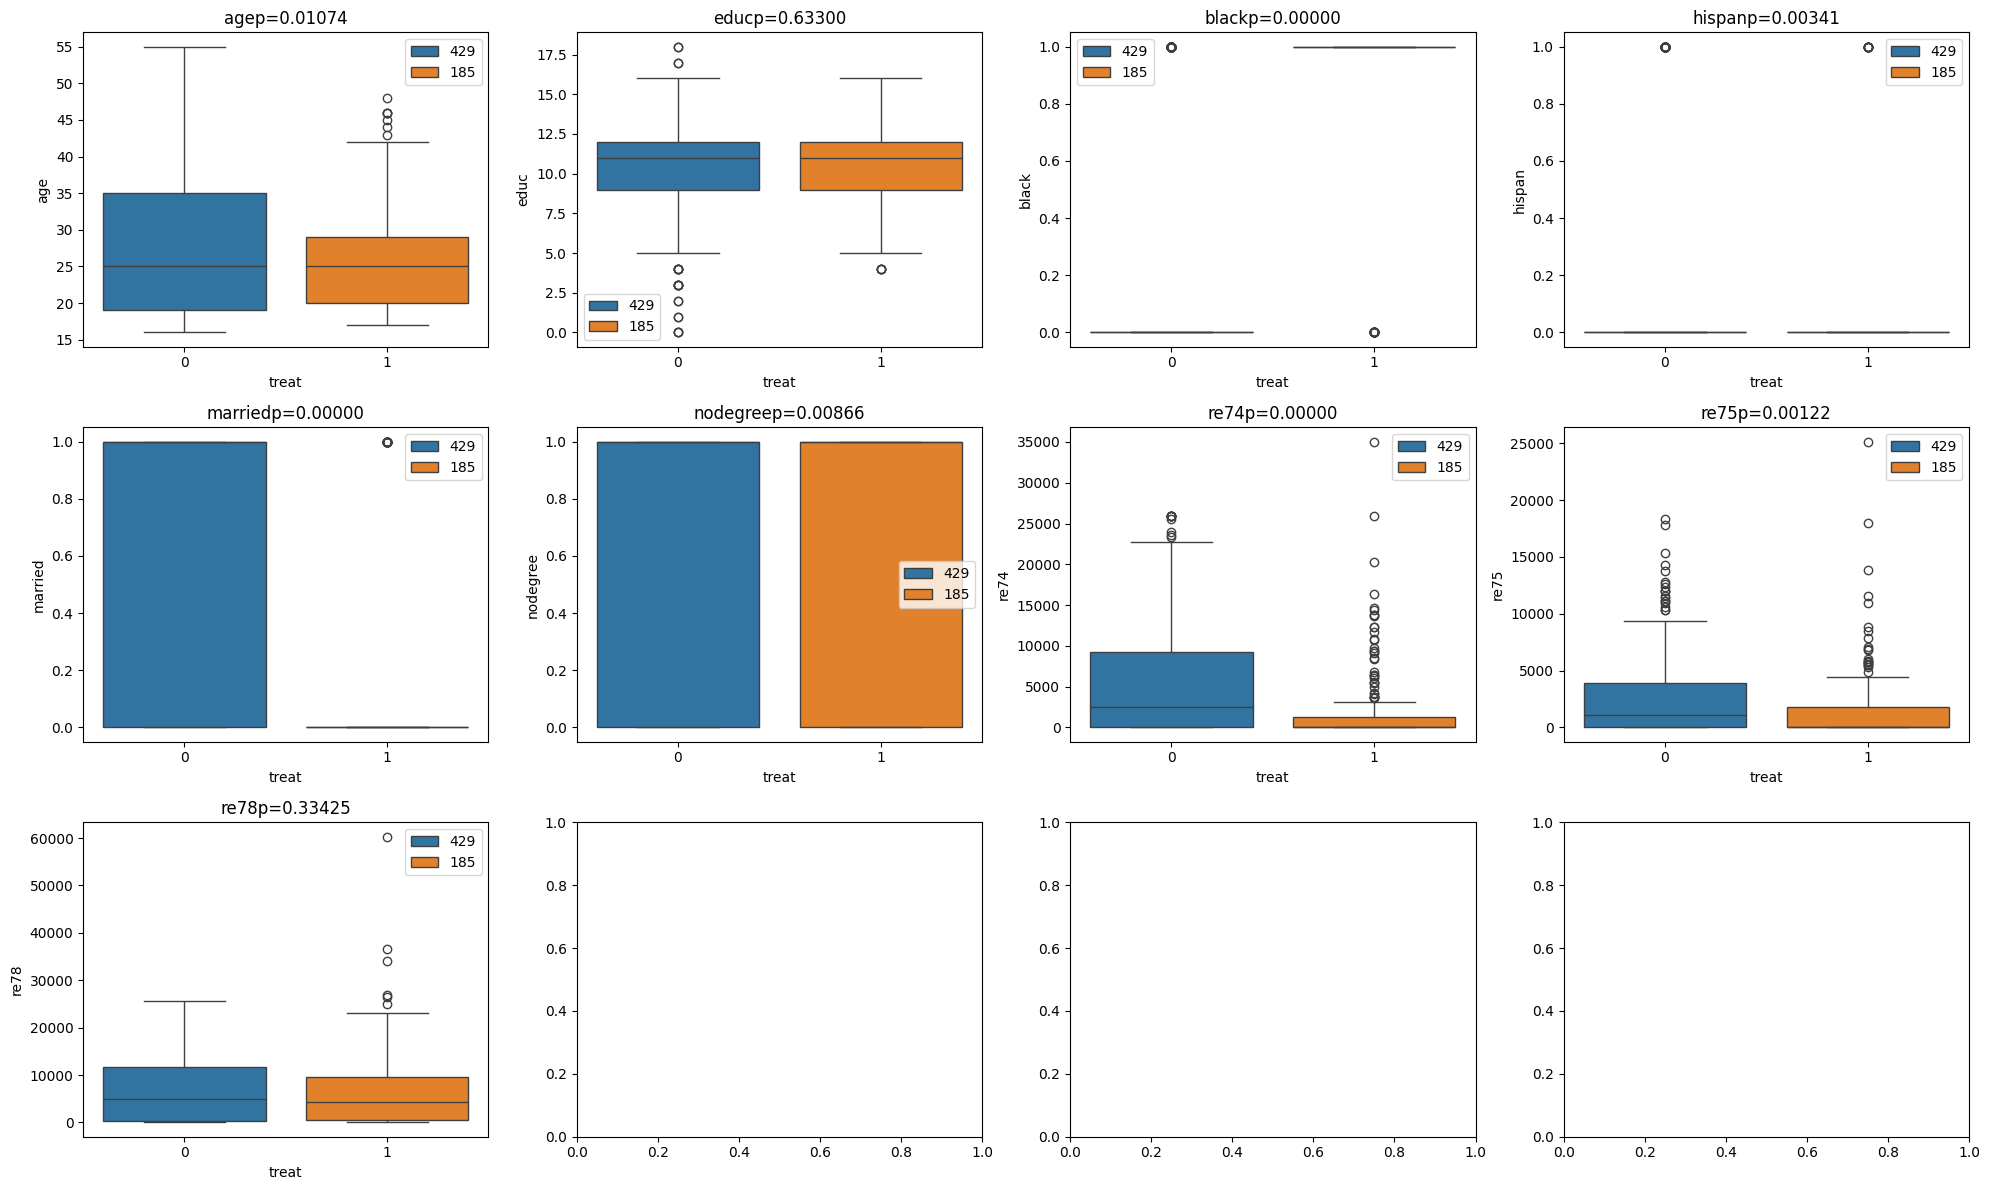

In [ ]:
columns = [c for c in df.columns if c!= 'treat' and c!='id']

n_cols = 4 
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(data=df, x='treat', y=col, hue='treat', ax=axes[i])
    t, p = ttest_ind(df[df['treat']==1][col],df[df['treat']==0][col])
    axes[i].set_title(col + f"p={p:.5f}")
    counts = df.groupby('treat')[col].count()
    axes[i].legend(counts)

plt.tight_layout()
plt.show()


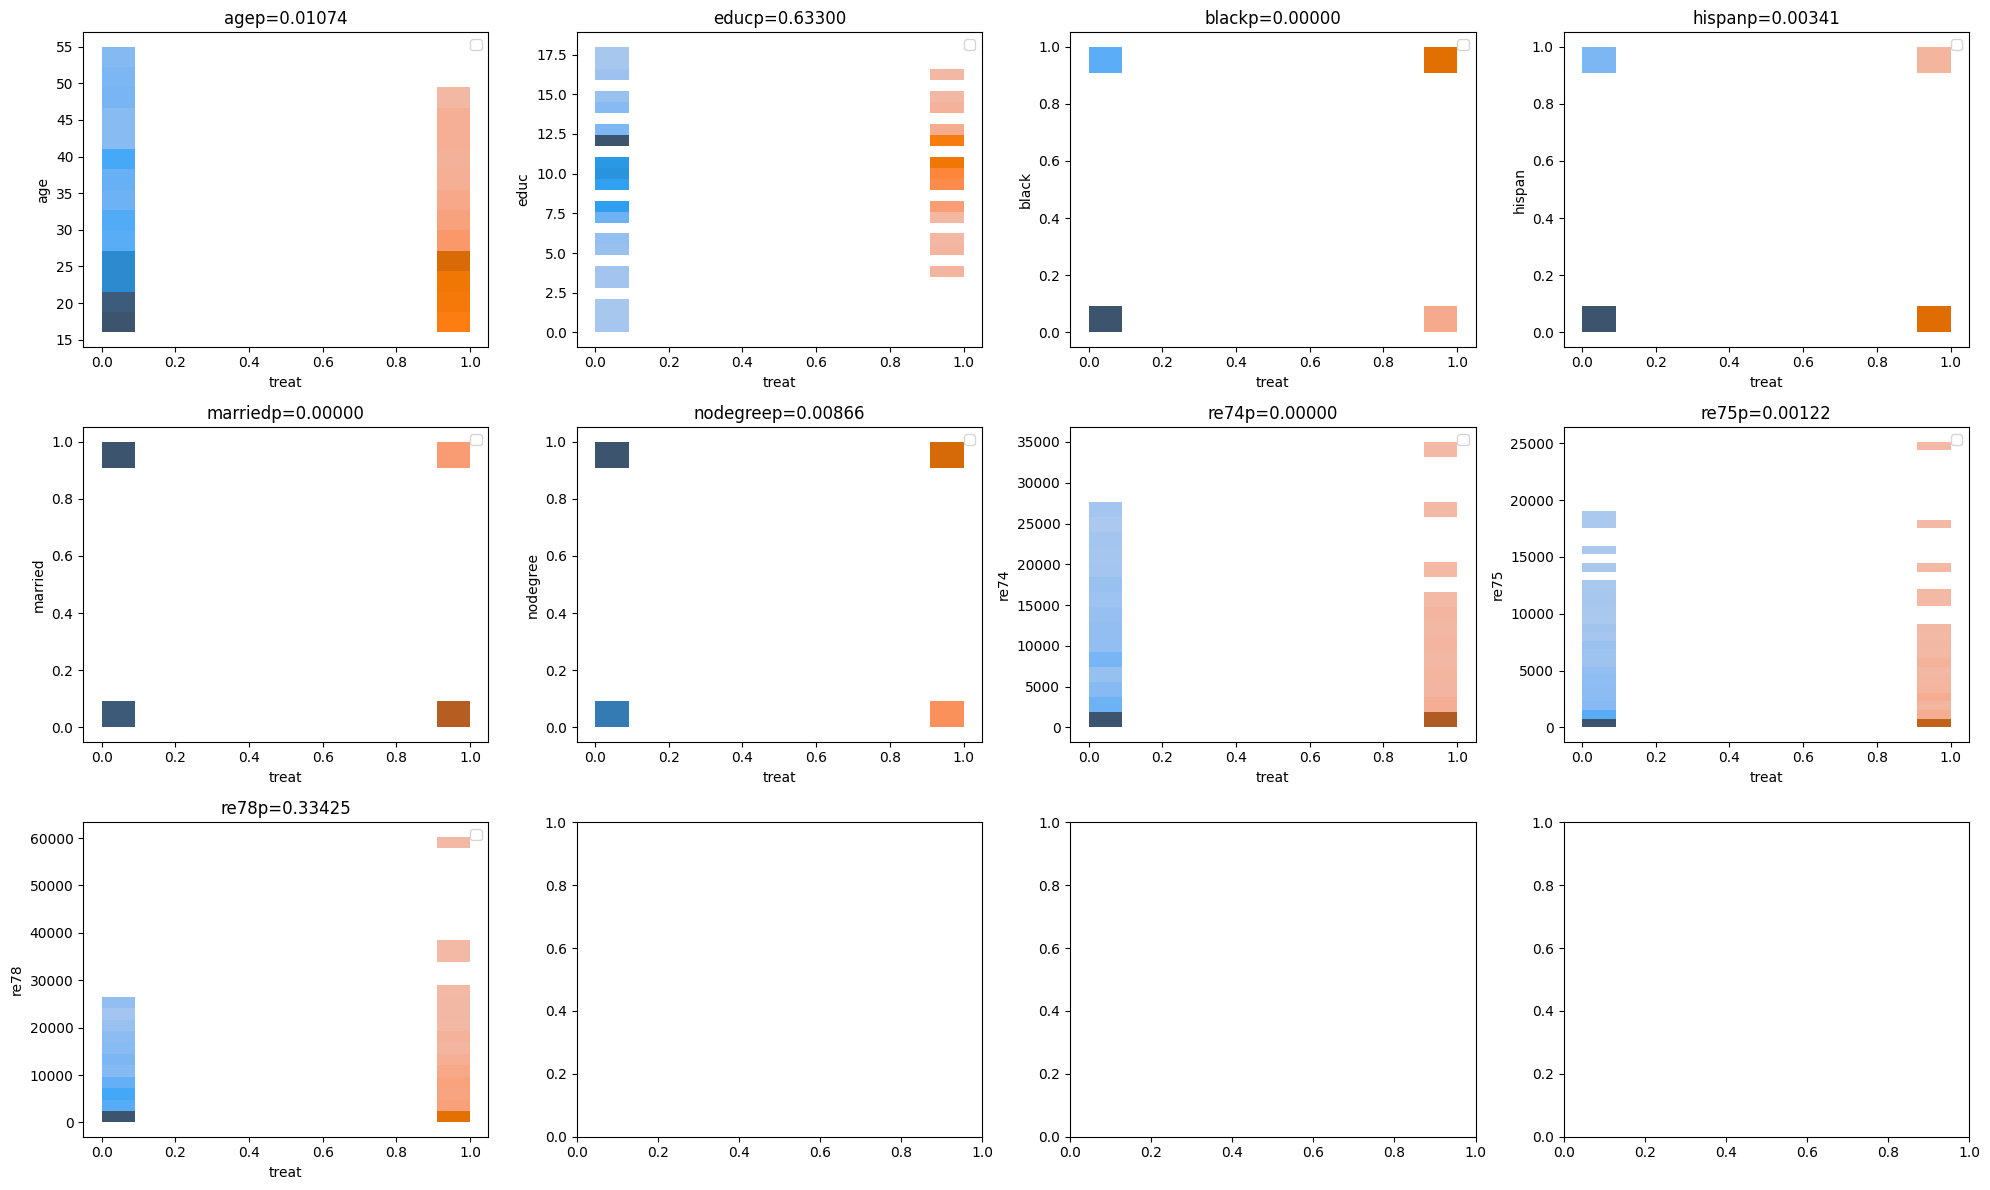

In [ ]:
columns = [c for c in df.columns if c!= 'treat' and c!='id']

n_cols = 4 
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(data=df, x='treat', y=col, hue='treat', ax=axes[i])
    t, p = ttest_ind(df[df['treat']==1][col],df[df['treat']==0][col])
    axes[i].set_title(col + f"p={p:.5f}")
    counts = df.groupby('treat')[col].count()
    axes[i].legend(counts)

plt.tight_layout()
plt.show()


## 3. A propensity score model

Use logistic regression to estimate propensity scores for all points in the dataset.
You may use `statsmodels` to fit the logistic regression model and apply it to each data point to obtain propensity scores.

Recall that the propensity score of a data point represents its probability of receiving the treatment, based on its pre-treatment features (in this case, age, education, pre-treatment income, etc.).
To brush up on propensity scores, you may read chapter 3.3 of the above-cited book by Rosenbaum or [this article](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3144483/pdf/hmbr46-399.pdf).

Note: you do not need a train/test split here. Train and apply the model on the entire dataset. If you're wondering why this is the right thing to do in this situation, recall that the propensity score model is not used in order to make predictions about unseen data. Its sole purpose is to balance the dataset across treatment groups.
(See p. 74 of Rosenbaum's book for an explanation why slight overfitting is even good for propensity scores.
If you want even more information, read [this article](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3144483/pdf/hmbr46-399.pdf).)

In [ ]:
import statsmodels.formula.api as smf

reg = smf.logit(formula='treat ~ age + educ + C(black) + C(hispan) + C(married) + C(nodegree) + re74 + re75', data=df)
res = reg.fit()
print(res.summary())

Optimization terminated successfully.
         Current function value: 0.397267
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  treat   No. Observations:                  614
Model:                          Logit   Df Residuals:                      605
Method:                           MLE   Df Model:                            8
Date:                Fri, 17 Oct 2025   Pseudo R-squ.:                  0.3508
Time:                        11:08:02   Log-Likelihood:                -243.92
converged:                       True   LL-Null:                       -375.75
Covariance Type:            nonrobust   LLR p-value:                 2.194e-52
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.7286      1.017     -4.649      0.000      -6.722      -2.735
C(black)[T.

In [ ]:
df['propensity_score'] = res.predict(df)
print(df.head())

     id  treat  age  educ  black  hispan  married  nodegree  re74  re75  \
0  NSW1      1   37    11      1       0        1         1   0.0   0.0   
1  NSW2      1   22     9      0       1        0         1   0.0   0.0   
2  NSW3      1   30    12      1       0        0         0   0.0   0.0   
3  NSW4      1   27    11      1       0        0         1   0.0   0.0   
4  NSW5      1   33     8      1       0        0         1   0.0   0.0   

         re78  propensity_score  
0   9930.0460          0.638770  
1   3595.8940          0.224634  
2  24909.4500          0.678244  
3   7506.1460          0.776324  
4    289.7899          0.701639  


## 4. Balancing the dataset via matching

Use the propensity scores to match each data point from the treated group with exactly one data point from the control group, while ensuring that each data point from the control group is matched with at most one data point from the treated group.
(Hint: you may explore the `networkx` package in Python for predefined matching functions.)

Your matching should maximize the similarity between matched subjects, as captured by their propensity scores.
In other words, the sum (over all matched pairs) of absolute propensity-score differences between the two matched subjects should be minimized.

This is how networkx library can help you do this. Each possible pair of (treated_person, control_person) is characterized by a similarity. This is how we can initialize a graph, and add an edge for one possible pair. We then need to add an edge for each possible pair.
    - G = nx.Graph()
    - G.add_weighted_edges_from([(control_person, treated_person, similarity)])
Optimal matching is then found with:
    - matching = nx.max_weight_matching(G)

After matching, you have as many treated as you have control subjects.
Compare the outcomes (`re78`) between the two groups (treated and control).

Also, compare again the feature-value distributions between the two groups, as you've done in part 2 above, but now only for the matched subjects.
What do you observe?
Are you closer to being able to draw valid conclusions now than you were before?

In [ ]:
# Build bipartite graph between treated and control observations
score_dfs = df[['propensity_score','treat']].copy()
g = nx.Graph()
score_dfs_treated = score_dfs[score_dfs.treat == 1]
score_dfs_non_treated = score_dfs[score_dfs.treat == 0]

# Add nodes with bipartite attribute
g.add_nodes_from(list(score_dfs_treated.index), bipartite='treated')
g.add_nodes_from(list(score_dfs_non_treated.index), bipartite='control')

# Add edges only between treated and control; weight is similarity (higher=better)
for i, r in score_dfs_treated.iterrows():
    for j, q in score_dfs_non_treated.iterrows():
        similarity = 1 - abs(r['propensity_score'] - q['propensity_score'])
        # ensure similarity is between 0 and 1
        similarity = max(0.0, min(1.0, similarity))
        g.add_edge(r.name, q.name, weight=similarity)

# Request maximum-weight matching with maximum cardinality so as many treated get matched as possible
matching = nx.max_weight_matching(g, maxcardinality=True)
# matching is a set of (u,v) pairs; print size and a few pairs for inspection
print('Number of matched pairs:', len(matching))
print(list(matching)[:10])

Number of matched pairs: 185
[(423, 20), (243, 71), (15, 387), (555, 151), (82, 456), (19, 601), (96, 369), (179, 364), (414, 148), (232, 110)]


In [ ]:
# Flatten the set of tuples into a list of all matched indices
matched_indices = set([i for pair in matching for i in pair])
# Keep only those rows in df
matched_df = df.loc[df.index.isin(matched_indices)].copy()
print(matched_df.head())

     id  treat  age  educ  black  hispan  married  nodegree  re74  re75  \
0  NSW1      1   37    11      1       0        1         1   0.0   0.0   
1  NSW2      1   22     9      0       1        0         1   0.0   0.0   
2  NSW3      1   30    12      1       0        0         0   0.0   0.0   
3  NSW4      1   27    11      1       0        0         1   0.0   0.0   
4  NSW5      1   33     8      1       0        0         1   0.0   0.0   

         re78  propensity_score  
0   9930.0460          0.638770  
1   3595.8940          0.224634  
2  24909.4500          0.678244  
3   7506.1460          0.776324  
4    289.7899          0.701639  


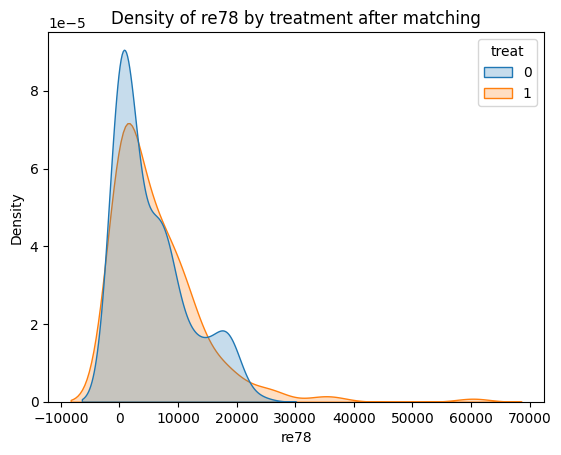

Mean for treated : 6349.143530270271 std : 7867.402217734687
Mean for not treated : 5454.7760499999995 std : 6063.836915562398


In [ ]:
sns.kdeplot(data=matched_df, x='re78', hue='treat', fill=True, common_norm=False)
plt.title("Density of re78 by treatment after matching")
plt.show()
print(f"Mean for treated : {matched_df[matched_df['treat']==1]['re78'].mean()} std : {matched_df[matched_df['treat']==1]['re78'].std()}")
print(f"Mean for not treated : {matched_df[matched_df['treat']==0]['re78'].mean()} std : {matched_df[matched_df['treat']==0]['re78'].std()}")

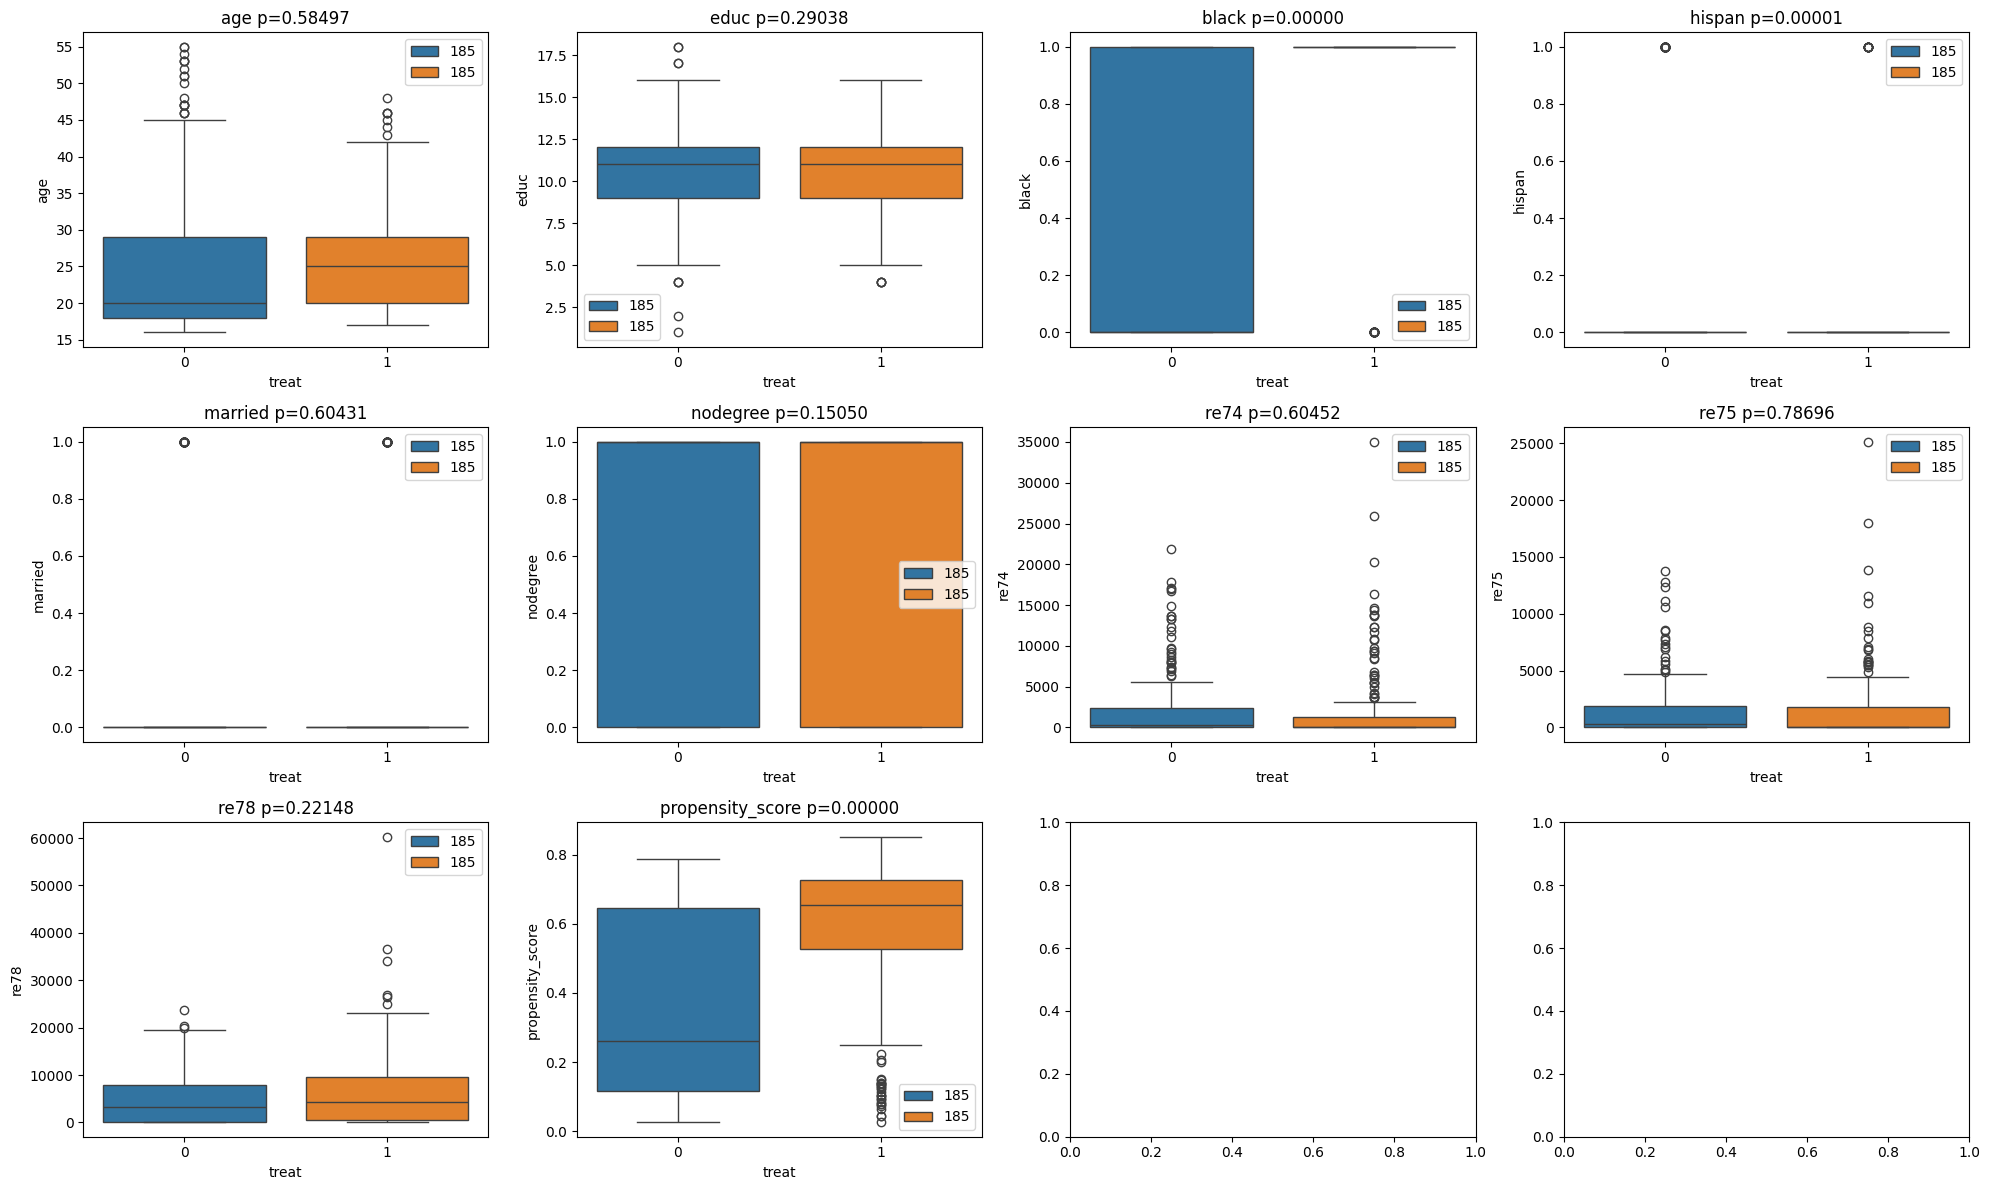

In [ ]:
columns = [c for c in matched_df.columns if c!= 'treat' and c!='id']

n_cols = 4 
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(data=matched_df, x='treat', y=col, hue='treat', ax=axes[i])
    t, p = ttest_ind(matched_df[matched_df['treat']==1][col],matched_df[matched_df['treat']==0][col])
    axes[i].set_title(col + f" p={p:.5f}")
    counts = matched_df.groupby('treat')[col].count()
    axes[i].legend(counts)

plt.tight_layout()
plt.show()


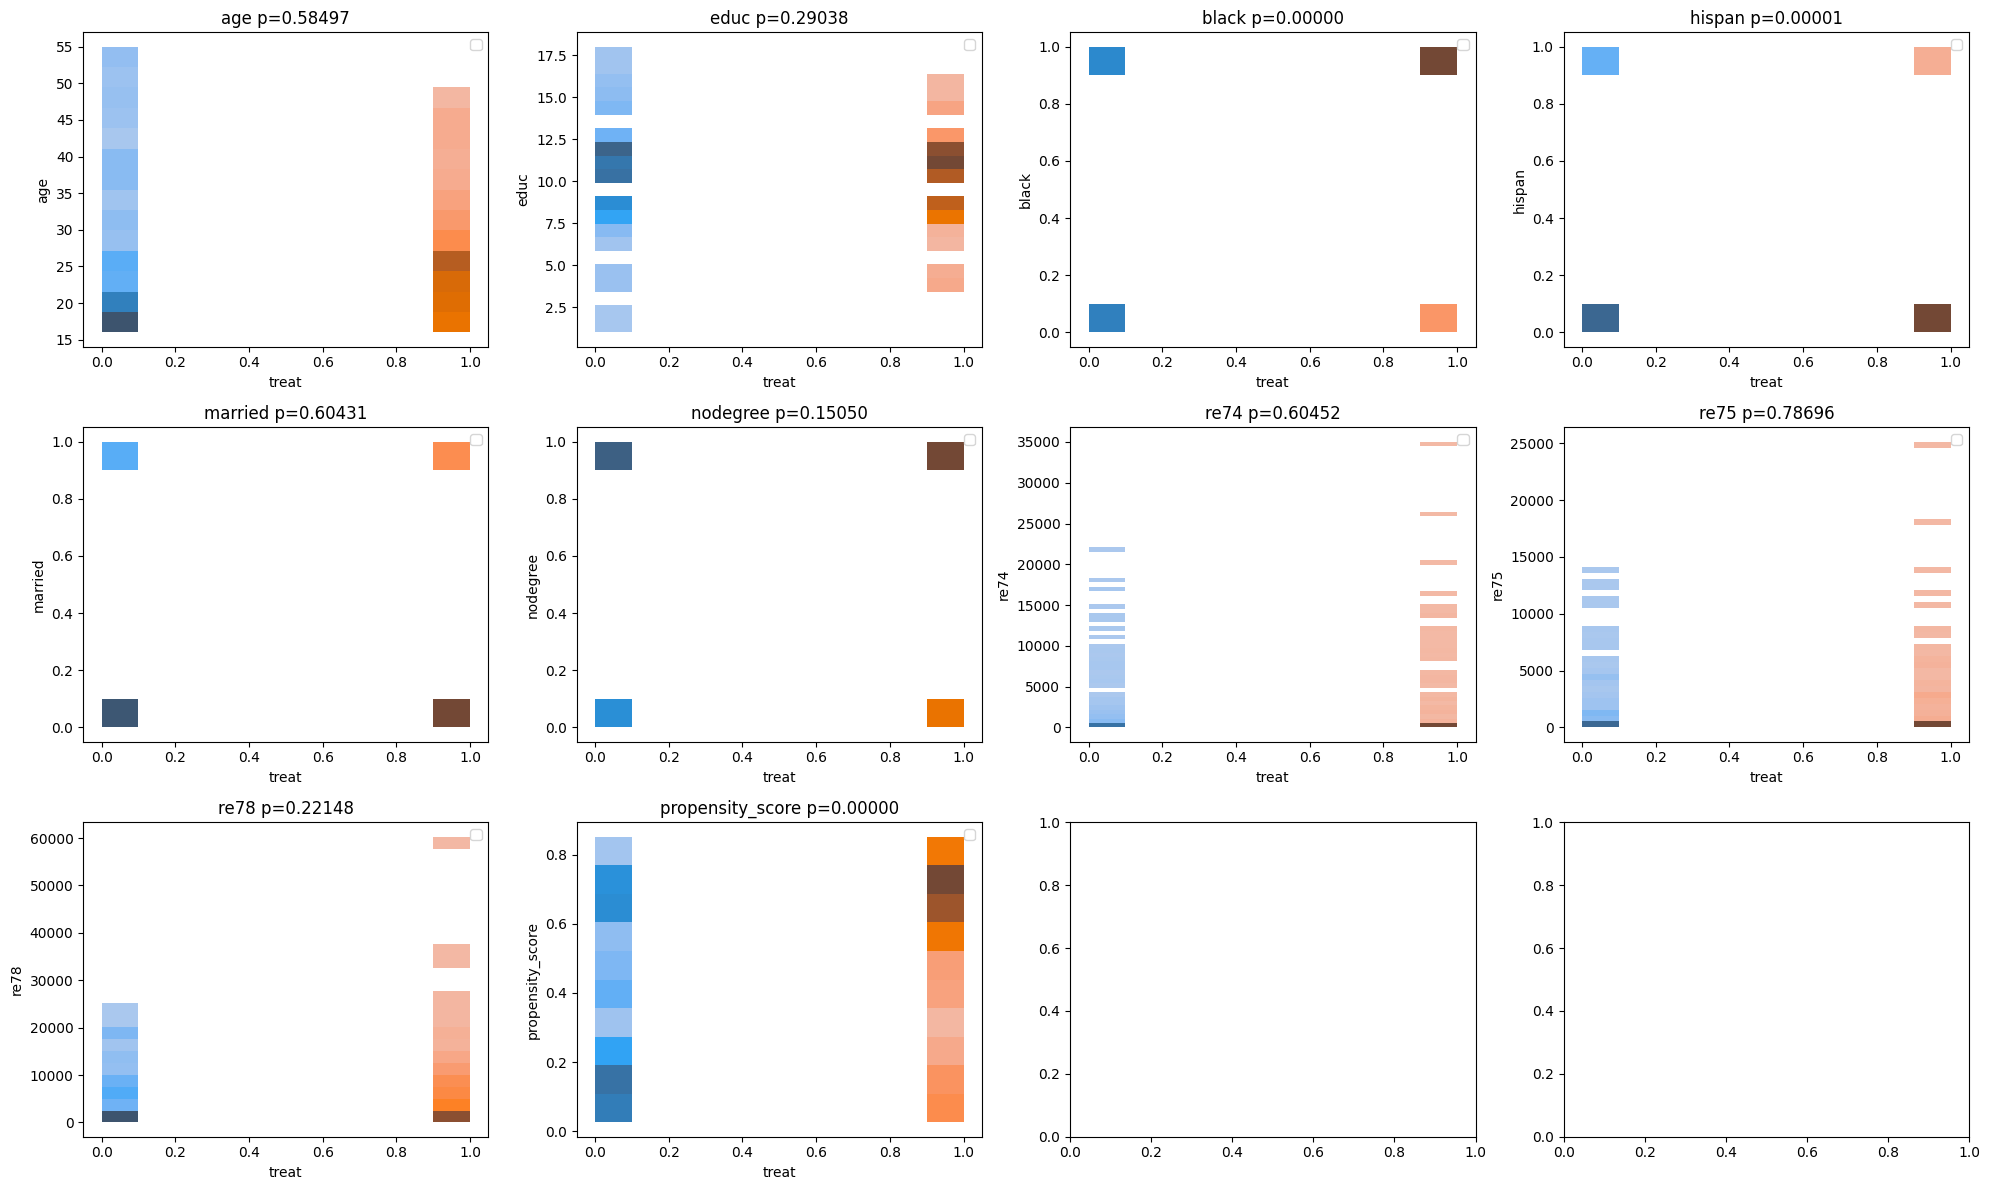

In [ ]:
columns = [c for c in matched_df.columns if c!= 'treat' and c!='id']

n_cols = 4 
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(data=matched_df, x='treat', y=col, hue='treat', ax=axes[i])
    t, p = ttest_ind(matched_df[matched_df['treat']==1][col],matched_df[matched_df['treat']==0][col])
    axes[i].set_title(col + f" p={p:.5f}")
    counts = matched_df.groupby('treat')[col].count()
    axes[i].legend(counts)

plt.tight_layout()
plt.show()

## 5. Balancing the groups further

Based on your comparison of feature-value distributions from part 4, are you fully satisfied with your matching?
Would you say your dataset is sufficiently balanced?
If not, in what ways could the "balanced" dataset you have obtained still not allow you to draw valid conclusions?

Improve your matching by explicitly making sure that you match only subjects that have the same value for the problematic feature.
Argue with numbers and plots that the two groups (treated and control) are now better balanced than after part 4.


In [ ]:
further_balanced_matching = []
questionable_variables = ['black', 'hispan']
for pair in matching:
    if all(matched_df.loc[pair[0]][v] == matched_df.loc[pair[1]][v] for v in questionable_variables):
        further_balanced_matching.append(pair)


further_matched_indices = set([i for pair in further_balanced_matching for i in pair])
# Keep only those rows in df
further_matched_df = df.loc[df.index.isin(further_matched_indices)].copy()
print(further_matched_df.head())

     id  treat  age  educ  black  hispan  married  nodegree  re74  re75  \
0  NSW1      1   37    11      1       0        1         1   0.0   0.0   
3  NSW4      1   27    11      1       0        0         1   0.0   0.0   
4  NSW5      1   33     8      1       0        0         1   0.0   0.0   
6  NSW7      1   23    12      1       0        0         0   0.0   0.0   
7  NSW8      1   32    11      1       0        0         1   0.0   0.0   

        re78  propensity_score  
0  9930.0460          0.638770  
3  7506.1460          0.776324  
4   289.7899          0.701639  
6     0.0000          0.653684  
7  8472.1580          0.789723  


## 6. A less naive analysis

Compare the outcomes (`re78`) between treated and control subjects, as you've done in part 1, but now only for the matched dataset you've obtained from part 5.
What do you conclude about the effectiveness of the job training program?

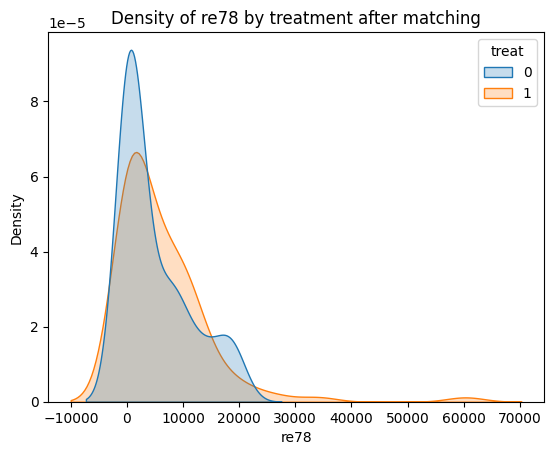

Mean for treated : 6193.564193203883 std : 8442.325278896024
Mean for not treated : 4929.208055825242 std : 6159.7817872267215
Wilcoxon test statistic: 2052.0, p-value: 0.3973832079458184


In [ ]:
sns.kdeplot(data=further_matched_df, x='re78', hue='treat', fill=True, common_norm=False)
plt.title("Density of re78 by treatment after matching")
plt.show()
print(f"Mean for treated : {further_matched_df[further_matched_df['treat']==1]['re78'].mean()} std : {further_matched_df[further_matched_df['treat']==1]['re78'].std()}")
print(f"Mean for not treated : {further_matched_df[further_matched_df['treat']==0]['re78'].mean()} std : {further_matched_df[further_matched_df['treat']==0]['re78'].std()}")
# wilcoxon test
from scipy.stats import wilcoxon
stat, p = wilcoxon(further_matched_df[further_matched_df['treat']==1]['re78'], further_matched_df[further_matched_df['treat']==0]['re78'])
print(f"Wilcoxon test statistic: {stat}, p-value: {p}")

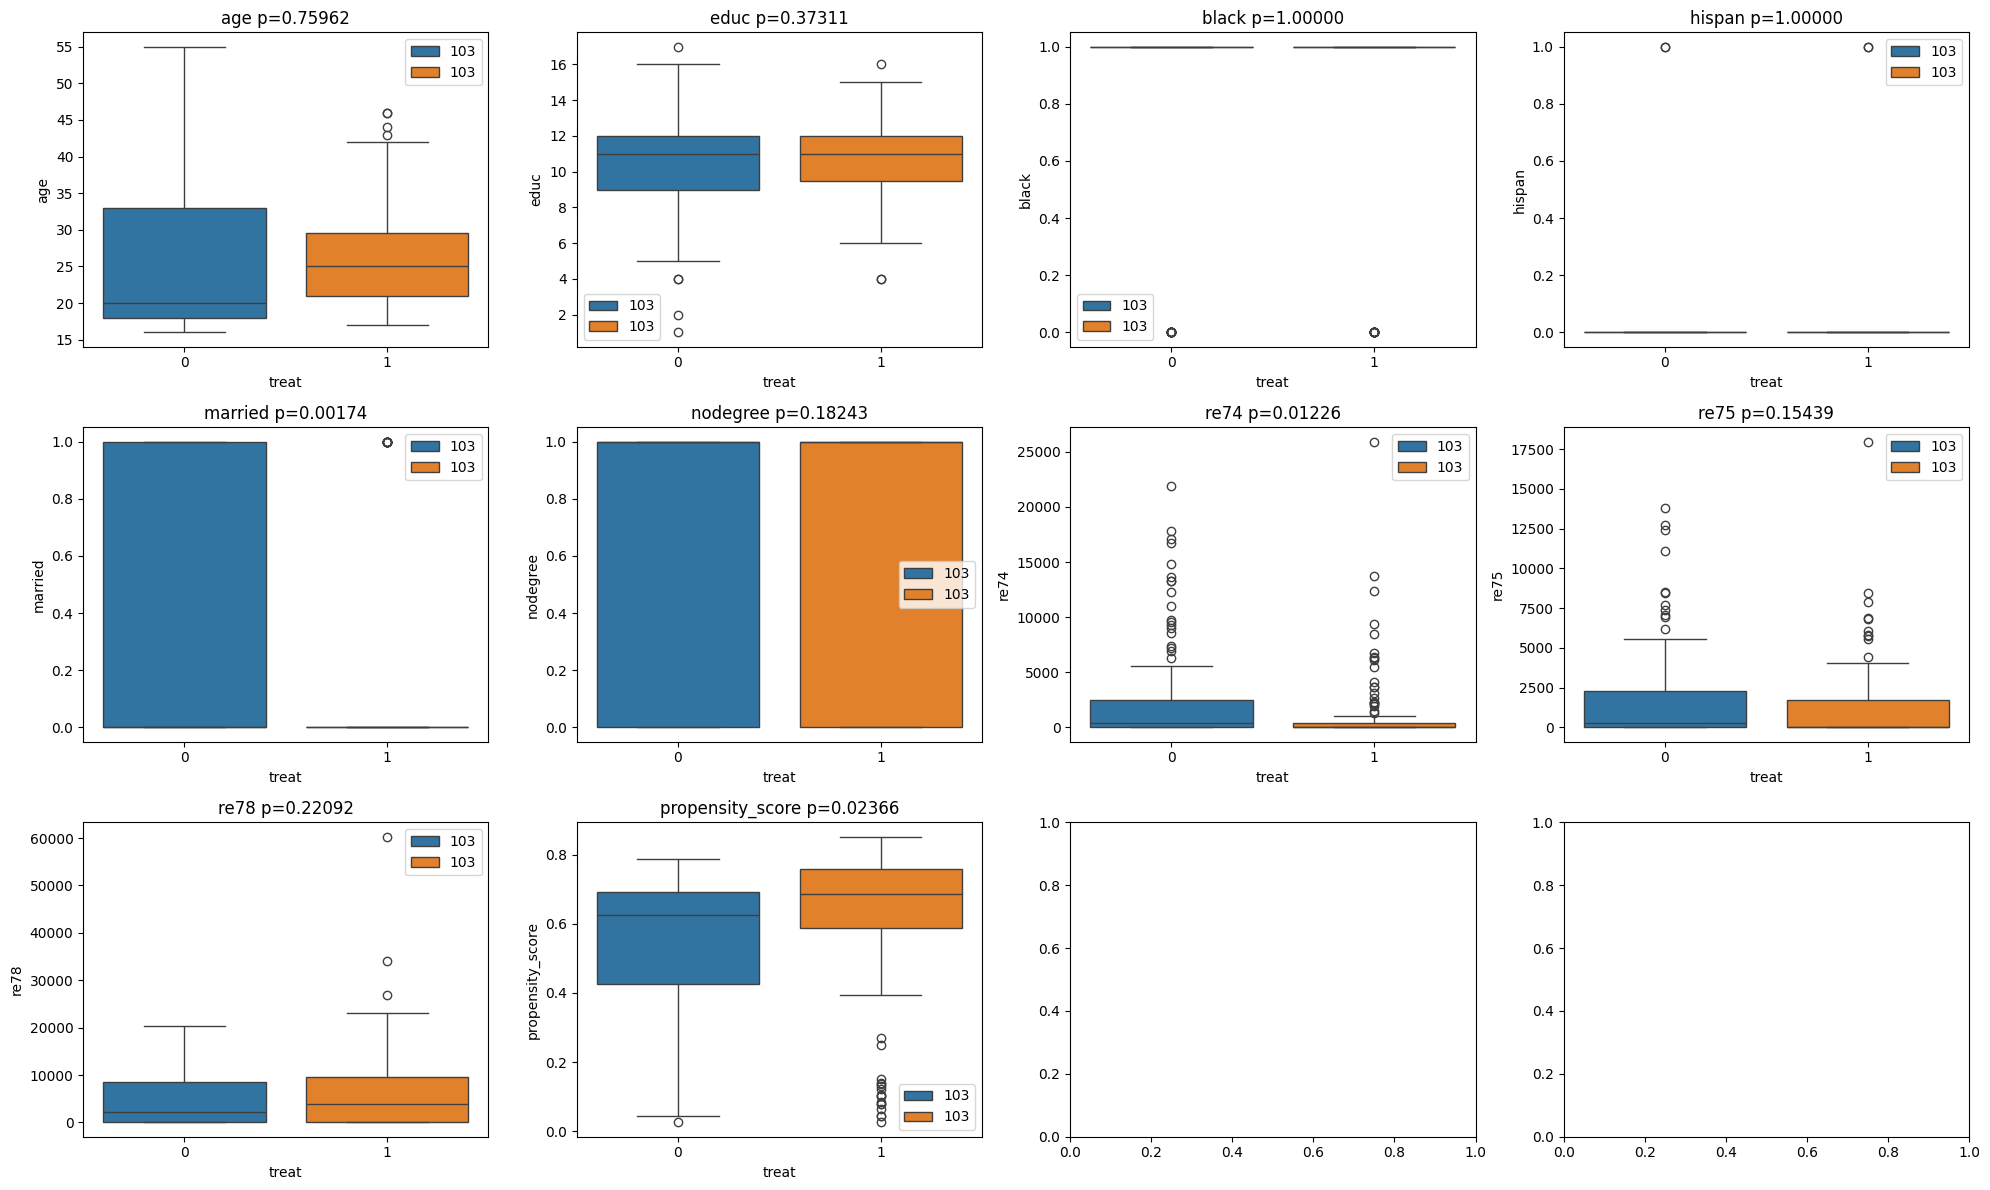

In [ ]:
columns = [c for c in further_matched_df.columns if c!= 'treat' and c!='id']

n_cols = 4 
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(data=further_matched_df, x='treat', y=col, hue='treat', ax=axes[i])
    t, p = ttest_ind(further_matched_df[further_matched_df['treat']==1][col],further_matched_df[further_matched_df['treat']==0][col])
    axes[i].set_title(col + f" p={p:.5f}")
    counts = further_matched_df.groupby('treat')[col].count()
    axes[i].legend(counts)

plt.tight_layout()
plt.show()